In [1]:
import importlib
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "plotly": "plotly",
    "matplotlib": "matplotlib"
}

missing = []
for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


# Answer to Section 1: Clean the dataset  (in this section, insert as many cells as needed) 

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

base_dir = Path.cwd()
data_dir = base_dir / "data" if (base_dir / "data").exists() else base_dir.parent / "data"

df1 = pd.read_csv(
                 data_dir / "Dataset1.csv",
                 encoding="cp1252",
                 low_memory=False
)
df2 = pd.read_csv(
                 data_dir / "Dataset2.csv",
                 encoding="cp1252",
                 low_memory=False
)

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 34 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   accounting_date           1037197 non-null  float64
 1   company_code              1037205 non-null  int64  
 2   customer_code             1037203 non-null  str    
 3   customer_district_code    1037201 non-null  float64
 4   item_code                 1037204 non-null  str    
 5   business_area_code        1037204 non-null  str    
 6   item_group_code           1037204 non-null  str    
 7   item_class_code           1037203 non-null  str    
 8   item_type                 1037133 non-null  float64
 9   bonus_group_code          1037202 non-null  str    
 10  environment_group_code    1037204 non-null  str    
 11  technology_group_code     1037203 non-null  str    
 12  commission_group_code     1037199 non-null  str    
 13  reporting_classification  1037199 non-

In [8]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 951177 entries, 0 to 951176
Data columns (total 34 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accounting_date           951177 non-null  int64  
 1   company_code              951158 non-null  float64
 2   customer_code             951168 non-null  str    
 3   customer_district_code    951172 non-null  float64
 4   item_code                 951172 non-null  str    
 5   business_area_code        951172 non-null  str    
 6   item_group_code           951171 non-null  str    
 7   item_class_code           951164 non-null  str    
 8   item_type                 951163 non-null  float64
 9   bonus_group_code          951164 non-null  str    
 10  environment_group_code    951150 non-null  str    
 11  technology_group_code     951162 non-null  str    
 12  commission_group_code     951162 non-null  str    
 13  reporting_classification  951164 non-null  str    
 14 

In [9]:
# Join the DataFrames
df = pd.concat([df1,df2], ignore_index= True)

In [10]:
df.shape

(1988382, 34)

## Cleaning the Dataset

In [11]:
#Print missing values
missing_values = df.isnull()
missing_values

,accounting_date,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,...,value_sales,value_cost,value_quantity,value_price_adjustment,currency,item_source_class,invoice_number,line_number,customer_order_number,dss_update_time
0,True,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,False,False,False,True,False,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988377,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1988378,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1988379,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1988380,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [12]:
#Print sum of missing values for each column
missing_counter = df.isnull().sum()
missing_counter

accounting_date                   8
company_code                     19
customer_code                    11
customer_district_code            9
item_code                         6
business_area_code                6
item_group_code                   7
item_class_code                  15
item_type                        86
bonus_group_code                 16
environment_group_code           28
technology_group_code            17
commission_group_code            21
reporting_classification         19
light_source                     12
warehouse_code                   15
abc_class_code                   17
abc_class_volume                  5
business_chain_l1_code            7
business_chain_l1_name           11
contact_method_code               9
salesperson_code                 19
order_type_code                  17
market_segment                    5
value_sales                       2
value_cost                        0
value_quantity                    2
value_price_adjustment      

In [13]:
# We removed the entire column because it completely consists of null values.
df_cleaned = df.drop(columns = ["item_source_class"], inplace = True)
print(df.isnull().sum())
df.shape                                                             

accounting_date              8
company_code                19
customer_code               11
customer_district_code       9
item_code                    6
business_area_code           6
item_group_code              7
item_class_code             15
item_type                   86
bonus_group_code            16
environment_group_code      28
technology_group_code       17
commission_group_code       21
reporting_classification    19
light_source                12
warehouse_code              15
abc_class_code              17
abc_class_volume             5
business_chain_l1_code       7
business_chain_l1_name      11
contact_method_code          9
salesperson_code            19
order_type_code             17
market_segment               5
value_sales                  2
value_cost                   0
value_quantity               2
value_price_adjustment       1
currency                     0
invoice_number               1
line_number                  2
customer_order_number        1
dss_upda

(1988382, 33)

In [14]:
# This row is a bit suspicious because it seems it contains too many null values hidden as "NA". Checked the unique values.
print(df['contact_method_code'].unique())

<StringArray>
['NA                            ',                              nan,
 'FAX                           ', 'NIM                           ',
 'EDI                           ', 'CFM                           ',
 'KAW                           ', 'ERA                           ',
 'MEG                           ', 'TRI                           ',
 ...
 'GOR                           ', 'JRE                           ',
 'RGA                           ', 'LDT                           ',
 'ENX                           ', 'BUD                           ',
 'ADB                           ', 'SPT                           ',
 'S                             ', 'SZA                           ']
Length: 1666, dtype: str


In [15]:
# After checking the unique values, we stripped the reduntant space and checked how many null values there are.
df['contact_method_code'] = df['contact_method_code'].str.strip()
(df['contact_method_code'] == 'NA').sum()

np.int64(1901885)

In [16]:
# We removed the entire column because nearly all of the rows are completely consist of null values.
df_cleaned = df.drop(columns = ["contact_method_code"], inplace = True)
print(df.isnull().sum())
df.shape              

accounting_date              8
company_code                19
customer_code               11
customer_district_code       9
item_code                    6
business_area_code           6
item_group_code              7
item_class_code             15
item_type                   86
bonus_group_code            16
environment_group_code      28
technology_group_code       17
commission_group_code       21
reporting_classification    19
light_source                12
warehouse_code              15
abc_class_code              17
abc_class_volume             5
business_chain_l1_code       7
business_chain_l1_name      11
salesperson_code            19
order_type_code             17
market_segment               5
value_sales                  2
value_cost                   0
value_quantity               2
value_price_adjustment       1
currency                     0
invoice_number               1
line_number                  2
customer_order_number        1
dss_update_time              0
dtype: i

(1988382, 32)

In [17]:
# I removed the null values in these rows because there is no way to find out these values
# based on other columns. Besides, we have nearly a million data so removing a hundred rows
# will not have a significiant effect.
df_cleaned = df.dropna(subset = ["accounting_date",                                             
"customer_code","customer_district_code","item_code",
"item_type","bonus_group_code","environment_group_code",                                 
"technology_group_code","commission_group_code",       
"reporting_classification", "light_source",                
"warehouse_code", "abc_class_code","abc_class_volume",                  
"salesperson_code","order_type_code", "market_segment",                      
"currency", "invoice_number", "line_number",                  
"customer_order_number", "dss_update_time","company_code"]  , inplace = True)                           
print(df.isnull().sum())                                                                          
df.shape                                                                                        

accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             2
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      3
salesperson_code            0
order_type_code             0
market_segment              0
value_sales                 1
value_cost                  0
value_quantity              0
value_price_adjustment      1
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
dss_update_time             0
dtype: int64


(1988224, 32)

In [18]:
# Change "accounting_date" to datetime-like object.
df['Date'] = df['accounting_date'].astype(str)
df["Date"] = pd.to_datetime(df["Date"], format="%Y%m%d.0", errors="coerce")
df.head()

,accounting_date,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,...,value_sales,value_cost,value_quantity,value_price_adjustment,currency,invoice_number,line_number,customer_order_number,dss_update_time,Date
12,20200117.0,101.0,467400401,400.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,57.42,18.0,18.0,0.0,AUD,2173329.0,1.0,2822216.0,49:58.7,2020-01-17
13,20220420.0,101.0,277000802,200.0,GIGAW2000/4W,FLD,FLD03002,FLD03,1.0,Professional,...,11976.00,12.0,12.0,0.0,AUD,2210804.0,2.0,2850386.0,49:58.7,2022-04-20
14,20220404.0,101.0,361000417,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,120.60,36.0,36.0,0.0,AUD,2205124.0,1.0,2852375.0,49:58.7,2022-04-04
16,20200125.0,101.0,361000450,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,114.84,36.0,36.0,0.0,AUD,2177128.0,1.0,2825539.0,49:58.7,2020-01-25
17,20240427.0,101.0,361000417,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,3666.24,1152.0,1152.0,0.0,AUD,2213107.0,1.0,2860530.0,49:58.7,2024-04-27


In [19]:
# It seems there are some incorrect dates. We will use "errors='coerce'" argument and left incorrect dates as null values to locate and delete them afterwards.
df['Date'] = df['accounting_date'].astype(str)                                      
df["Date"]=pd.to_datetime(df["Date"], format="%Y%m%d.0", errors="coerce")
df.head()

,accounting_date,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,...,value_sales,value_cost,value_quantity,value_price_adjustment,currency,invoice_number,line_number,customer_order_number,dss_update_time,Date
12,20200117.0,101.0,467400401,400.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,57.42,18.0,18.0,0.0,AUD,2173329.0,1.0,2822216.0,49:58.7,2020-01-17
13,20220420.0,101.0,277000802,200.0,GIGAW2000/4W,FLD,FLD03002,FLD03,1.0,Professional,...,11976.00,12.0,12.0,0.0,AUD,2210804.0,2.0,2850386.0,49:58.7,2022-04-20
14,20220404.0,101.0,361000417,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,120.60,36.0,36.0,0.0,AUD,2205124.0,1.0,2852375.0,49:58.7,2022-04-04
16,20200125.0,101.0,361000450,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,114.84,36.0,36.0,0.0,AUD,2177128.0,1.0,2825539.0,49:58.7,2020-01-25
17,20240427.0,101.0,361000417,300.0,GENIE11WWWES,LMP,LMP01008,LMP01,5.0,Trade,...,3666.24,1152.0,1152.0,0.0,AUD,2213107.0,1.0,2860530.0,49:58.7,2024-04-27


In [20]:
df.isnull().sum()

accounting_date                0
company_code                   0
customer_code                  0
customer_district_code         0
item_code                      0
business_area_code             0
item_group_code                2
item_class_code                0
item_type                      0
bonus_group_code               0
environment_group_code         0
technology_group_code          0
commission_group_code          0
reporting_classification       0
light_source                   0
warehouse_code                 0
abc_class_code                 0
abc_class_volume               0
business_chain_l1_code         0
business_chain_l1_name         3
salesperson_code               0
order_type_code                0
market_segment                 0
value_sales                    1
value_cost                     0
value_quantity                 0
value_price_adjustment         1
currency                       0
invoice_number                 0
line_number                    0
customer_o

In [21]:
df_cleaned = df.dropna(subset = ["Date"]  , inplace = True)       
print(df.isnull().sum())                                                                    
df.shape                        

accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             2
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      3
salesperson_code            0
order_type_code             0
market_segment              0
value_sales                 1
value_cost                  0
value_quantity              0
value_price_adjustment      1
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
dss_update_time             0
Date                        0
dtype: int

(1985672, 33)

In [22]:
# Check every unique values of columns to see if there is any words or numbers which is written inaccurately..
columns = df.columns
for col in columns:
    unique_value = df[col].unique()
    print(f"{col} : {unique_value}")
    print("--------------------------------------------------------------------------------------------")

accounting_date : [20200117. 20220420. 20220404. ... 20231222. 20211222. 20221222.]
--------------------------------------------------------------------------------------------
company_code : [101. 100. 140. 205. 170. 220. 950. 240. 510. 120.]
--------------------------------------------------------------------------------------------
customer_code : <StringArray>
[ '467400401',  '277000802',  '361000417',  '361000450',  '299480709',
  '299502524',  '267401403',  '361000422',  '361000415',  '361001440',
 ...
  '800001900',  '287100100',  '102000200',  '219746502', 'Z85037301 ',
  '209900500', 'ZI8005601 ', 'ZI2000017 ', 'Z85020601 ',  '434790100']
Length: 4486, dtype: str
--------------------------------------------------------------------------------------------
customer_district_code : [400. 200. 300. 410. 210. 720. 500. 600. 310. 710. 510. 530. 535. 540.
 520. 545. 100.]
--------------------------------------------------------------------------------------------
item_code : <StringA

In [23]:
df["item_code"] = df["item_code"].str.strip()
df["business_area_code"] = df["business_area_code"].str.strip()
df["item_group_code"] = df["item_group_code"].str.strip()
df["bonus_group_code"] = df["bonus_group_code"].str.strip()
df["environment_group_code"] = df["environment_group_code"].str.strip()
df["technology_group_code"] = df["technology_group_code"].str.strip()
df["commission_group_code"] = df["commission_group_code"].str.strip()
df["business_chain_l1_code"] = df["business_chain_l1_code"].str.strip()
df["item_class_code"] = df["item_class_code"].str.strip()

In [24]:
# Check null values
df[df['item_group_code'].isnull()]

,accounting_date,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,bonus_group_code,...,value_sales,value_cost,value_quantity,value_price_adjustment,currency,invoice_number,line_number,customer_order_number,dss_update_time,Date
1029976,20221115.0,205.0,411900300,400.0,10026,LMP,NaN,LMP05,7.0,Trade,...,25.8,30.0,30.0,0.0,AUD,714678.0,0.0,803438.0,49:58.7,2022-11-15
1037230,20230422.0,205.0,471000815,400.0,10364,COM,NaN,COM03,5.0,Trade,...,450.0,281.4,60.0,0.0,AUD,744757.0,0.0,859314,49:58.7,2023-04-22


In [25]:
# It would be better to drop null values in these columns. It is possible to understand that null values in item_group_codes column above starts with 
# "LMP" and "COM" respectively. However, there is no way to figure out the numbers afterwards.
df_cleaned = df.dropna(subset = ["item_group_code","value_sales","value_price_adjustment"]  , inplace = True)       
print(df.isnull().sum())                                                                    

accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             0
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      3
salesperson_code            0
order_type_code             0
market_segment              0
value_sales                 0
value_cost                  0
value_quantity              0
value_price_adjustment      0
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
dss_update_time             0
Date                        0
dtype: int

In [26]:
df[df['business_chain_l1_name'].isnull()][["business_chain_l1_code","business_chain_l1_name"]]

,business_chain_l1_code,business_chain_l1_name
134,ELC,NaN
738596,ELC,NaN
738943,MED,NaN


In [27]:
#Getting the first non-null value.
first_non_null= df.loc[df["business_chain_l1_code"] == "ELC" , "business_chain_l1_name"].dropna().iloc[0]
first_non_null1 = df.loc[df["business_chain_l1_code"] == "MED" , "business_chain_l1_name"].dropna().iloc[0]      

print(first_non_null)
print(first_non_null1)

ElectraCorp Ltd
Metro Electrical Distributors


In [28]:
#Filling the null values based on other columns
df.loc[df["business_chain_l1_code"] == "ELC" , "business_chain_l1_name"] = df.loc[df["business_chain_l1_code"] == "ELC" , "business_chain_l1_name"].fillna(first_non_null)
df.loc[df["business_chain_l1_code"] == "MED" , "business_chain_l1_name"] = df.loc[df["business_chain_l1_code"] == "MED" , "business_chain_l1_name"].fillna(first_non_null1)
print(df.isnull().sum())

accounting_date             0
company_code                0
customer_code               0
customer_district_code      0
item_code                   0
business_area_code          0
item_group_code             0
item_class_code             0
item_type                   0
bonus_group_code            0
environment_group_code      0
technology_group_code       0
commission_group_code       0
reporting_classification    0
light_source                0
warehouse_code              0
abc_class_code              0
abc_class_volume            0
business_chain_l1_code      0
business_chain_l1_name      0
salesperson_code            0
order_type_code             0
market_segment              0
value_sales                 0
value_cost                  0
value_quantity              0
value_price_adjustment      0
currency                    0
invoice_number              0
line_number                 0
customer_order_number       0
dss_update_time             0
Date                        0
dtype: int

In [29]:
print((df['currency'] == '   ').sum())
print((df['warehouse_code'] == 'Unk').sum())
print((df['environment_group_code'] == 'NA').sum())
print((df['technology_group_code'] == 'NA').sum())

2
197020
162
210850


In [30]:
# Remove the rows which have "   " in currency column.
df = df[df['currency'] != '   ']

In [31]:
# Fix misspelling
df.loc[df['currency'].isin(["AUS"]), 'currency'] = 'AUD'

In [32]:
# These columns does not  have a vital affect on our data. So instead of removing the rows, I will change all of the null values as "UNKNOWN".
# The reason is, nearly 200 thousand rows has null values in these columns. Removing this amount will distort our data significantly.
#df.loc[df['warehouse_code'].isin(["Unk"]), 'warehouse_code'] = 'UNKNOWN'
#df.loc[df['environment_group_code'].isin(["NA"]), 'environment_group_code'] = 'UNKNOWN'
#df.loc[df['technology_group_code'].isin(["NA"]), 'technology_group_code'] = 'UNKNOWN'

In [33]:
# Check every unique values of columns to see if there is any words or numbers which is written inaccurately once again.
columns = df.columns
for col in columns:
    unique_value = df[col].unique()
    print(f"{col} : {unique_value}")
    print("--------------------------------------------------------------------------------------")
print(df.shape)

accounting_date : [20200117. 20220420. 20220404. ... 20231222. 20211222. 20221222.]
--------------------------------------------------------------------------------------
company_code : [101. 100. 140. 205. 170. 220. 950. 240. 510. 120.]
--------------------------------------------------------------------------------------
customer_code : <StringArray>
[ '467400401',  '277000802',  '361000417',  '361000450',  '299480709',
  '299502524',  '267401403',  '361000422',  '361000415',  '361001440',
 ...
  '800001900',  '287100100',  '102000200',  '219746502', 'Z85037301 ',
  '209900500', 'ZI8005601 ', 'ZI2000017 ', 'Z85020601 ',  '434790100']
Length: 4486, dtype: str
--------------------------------------------------------------------------------------
customer_district_code : [400. 200. 300. 410. 210. 720. 500. 600. 310. 710. 510. 530. 535. 540.
 520. 545. 100.]
--------------------------------------------------------------------------------------
item_code : <StringArray>
[   'GENIE11WWWES'

Text(0, 0.5, 'Value Quantity')

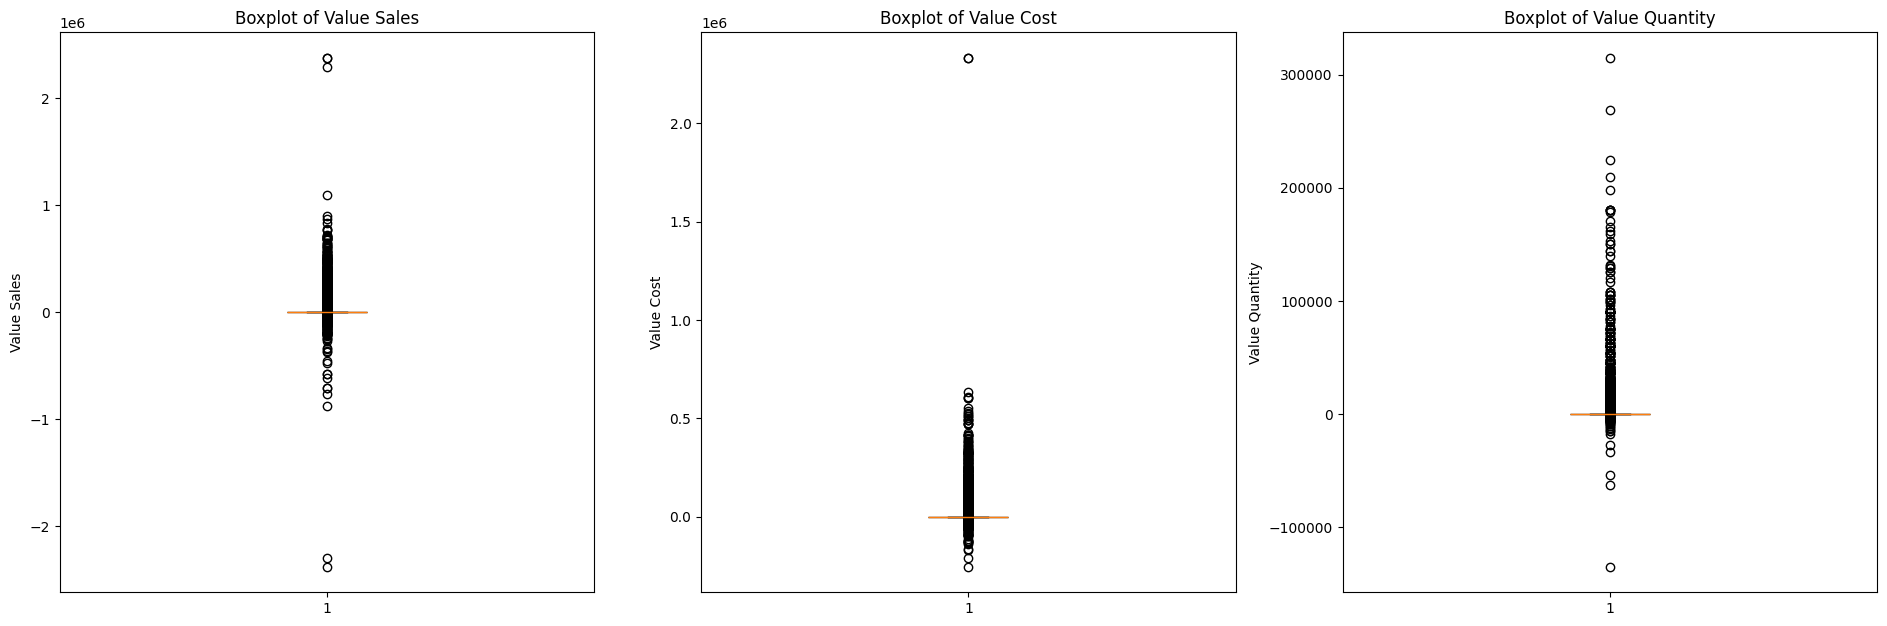

In [34]:
import matplotlib.pyplot as plt
# Value sales boxplot
plt.figure(figsize=(40, 16))

plt.subplot(2, 5, 1)
plt.boxplot(df['value_sales'], patch_artist=True)
plt.title('Boxplot of Value Sales')
plt.ylabel('Value Sales')

# Value cost boxplot
plt.subplot(2, 5, 2)
plt.boxplot(df['value_cost'], patch_artist=True)
plt.title('Boxplot of Value Cost')
plt.ylabel('Value Cost')

# Value quantity boxplot
plt.subplot(2, 5, 3)
plt.boxplot(df['value_quantity'], patch_artist=True)
plt.title('Boxplot of Value Quantity')
plt.ylabel('Value Quantity')

In [35]:
# Find IQR to replace outliers.
columns_list = ["value_sales", "value_cost", "value_quantity"]
lower_limits =[]
upper_limits= []
for column in columns_list:
    percentile25 = df[column].quantile(0.25)
    percentile75 = df[column].quantile(0.75)
    iqr = percentile75 - percentile25

    lower_limit = percentile25 - (1.5*iqr)
    lower_limits.append(lower_limit)
    
    upper_limit = percentile75 + (1.5*iqr)
    upper_limits.append(upper_limit)
    
    print(f"{column}\nLower Limit = {lower_limit:.2f} \nUpper Limit = {upper_limit:.2f}")
    print("--------------------------------------------------------------------------")
print(f"Lower Limits: {lower_limits} \nUpper Limits: {upper_limits}")

value_sales
Lower Limit = -717.00 
Upper Limit = 1379.16
--------------------------------------------------------------------------
value_cost
Lower Limit = -175.67 
Upper Limit = 324.78
--------------------------------------------------------------------------
value_quantity
Lower Limit = -75.00 
Upper Limit = 141.00
--------------------------------------------------------------------------
Lower Limits: [np.float64(-717.0), np.float64(-175.6698), np.float64(-75.0)] 
Upper Limits: [np.float64(1379.1599999999999), np.float64(324.783), np.float64(141.0)]


In [36]:
# Replace outliers with median values.
for i in range(3):
    df.loc[(df[columns_list[i]] > upper_limits[i]), columns_list[i]] = df[columns_list[i]].median()
    df.loc[(df[columns_list[i]] < lower_limits[i]), columns_list[i]] = df[columns_list[i]].median()

In [37]:
histogram_vis = df.copy()

In [38]:
# Check skewness
from scipy import stats
import numpy as np
for col in columns_list:
    skewness = histogram_vis[col].skew()
    print(f"{col}\nSkewness = {skewness}")
    print("----------------------------")

value_sales
Skewness = 1.4946778909717975
----------------------------
value_cost
Skewness = 1.8747199917123585
----------------------------
value_quantity
Skewness = 1.4817736606155631
----------------------------


In [39]:
# We will use "SQRT" method because it can handle zero values.
for col in columns_list:
    histogram_vis[col] = np.sqrt(histogram_vis[col])
    skewness_after = histogram_vis[col].skew()
    print(f"Skewness of '{col}': {skewness_after}")
    print("------------------------------------------------------")

c:\Users\aaliy\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Skewness of 'value_sales': 0.7612364711914085
------------------------------------------------------
Skewness of 'value_cost': 0.9558343402019516
------------------------------------------------------
Skewness of 'value_quantity': 0.6330276527209401
------------------------------------------------------


Text(0, 0.5, 'Frequency')

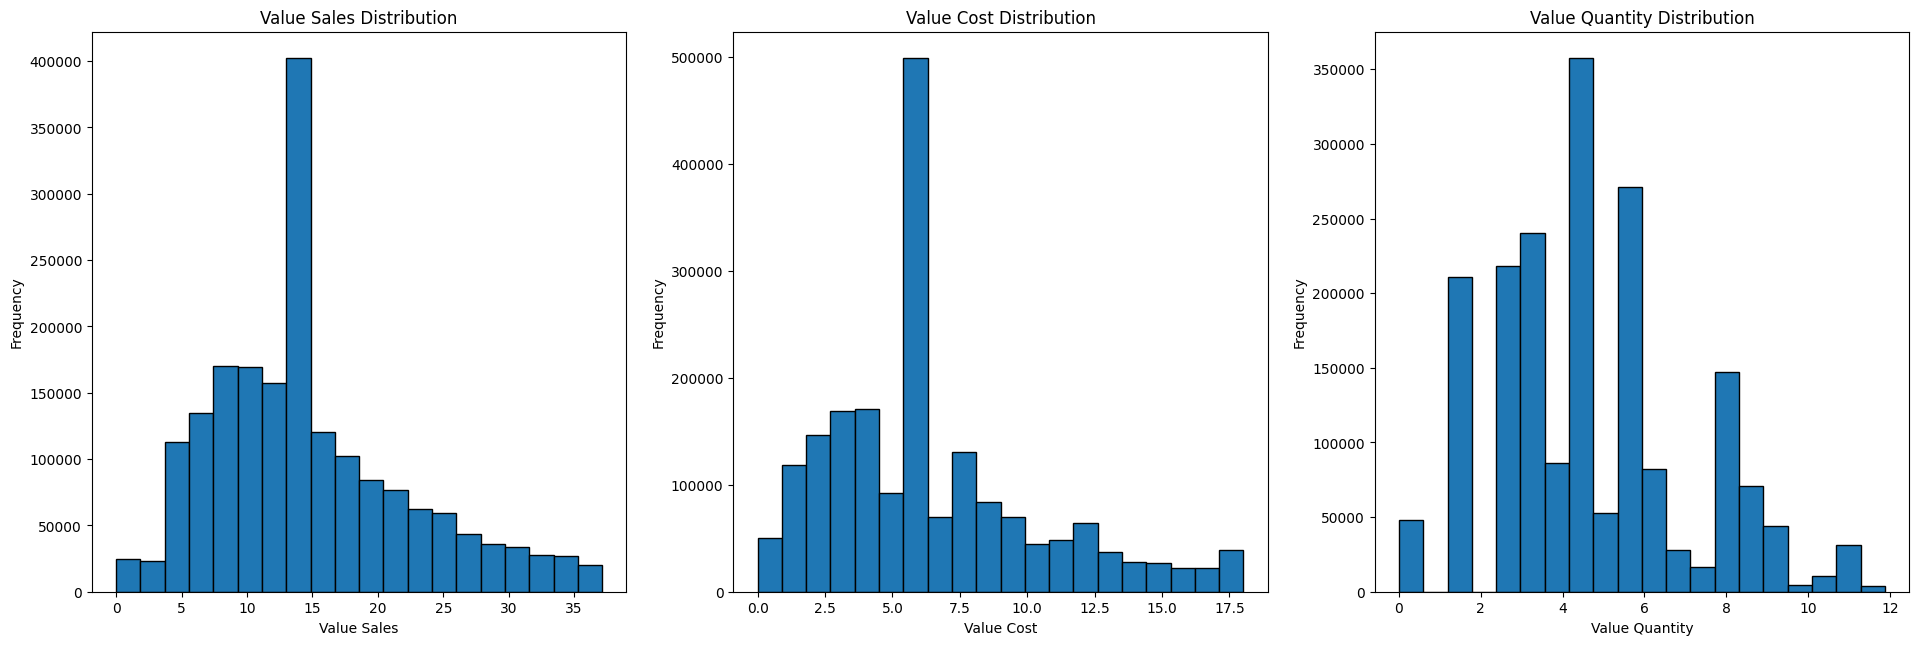

In [40]:
# Create histograms
plt.figure(figsize=(40, 16))

plt.subplot(2, 5, 1)
plt.hist(histogram_vis['value_sales'], bins=20, edgecolor='black')
plt.title('Value Sales Distribution')
plt.xlabel('Value Sales')
plt.ylabel('Frequency')

plt.subplot(2, 5, 2)
plt.hist(histogram_vis['value_cost'], bins=20, edgecolor='black')
plt.title('Value Cost Distribution')
plt.xlabel('Value Cost')
plt.ylabel('Frequency')

plt.subplot(2, 5, 3)
plt.hist(histogram_vis['value_quantity'], bins=20, edgecolor='black')
plt.title('Value Quantity Distribution')
plt.xlabel('Value Quantity')
plt.ylabel('Frequency')

# Answer Section 2: Exploratory Insights (all the codes in one cell - do not insert extra cells) 

## section 2.1 (all the codes in one cell - do not insert extra cells) 

In [41]:
import pandas as pd
import plotly.express as px

#Monthly Sales Trend Over Time
#Create Year-Month for time series
df['year_month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['value_sales'].mean().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)


#Aggregate sales by month
monthly_sales = (
    df
    .groupby("year_month", as_index=False)["value_sales"]
    .sum()
)

#Convert the PeriodDtype into actual datetime for plotting
monthly_sales["year_month"] = monthly_sales["year_month"].dt.to_timestamp()

#Create the Plotly Express figure
fig = px.line(
    monthly_sales,
    x="year_month",
    y="value_sales",
    title="Monthly Sales Trend Over Time",
    labels={
        "year_month": "Month",
        "value_sales": "Sales Value"
    },
    markers=True,
    template="plotly_white"
)

fig.update_traces(
    mode="lines+markers",
    line_shape="spline",
    line=dict(width=3, color=px.colors.sequential.Plasma[6]),
    marker=dict(size=7, color=px.colors.sequential.Plasma[3]),
    fill="tozeroy"
)

fig.update_layout(
    xaxis=dict(
        tickformat="%b %Y",
        dtick="M1",
        tickangle=-45,
        showgrid=False
    ),
    yaxis=dict(
        tickprefix="$",
        separatethousands=True,
        showgrid=True,
        gridcolor="lightgrey"
    ),
    title=dict(x=0.5, xanchor="center"),
    font=dict(family="Arial", size=12),
    margin=dict(l=40, r=40, t=60, b=60)
)

fig.show()


## section 2.2 (all the codes in one cell - do not insert extra cells) 

In [42]:
#Customer Retention Curve

#Build cohorts
df['order_period']  = df['Date'].dt.to_period('M')
df['cohort_period'] = (
    df.groupby('customer_code')['Date']
      .transform('min')
      .dt.to_period('M')
)
df['cohort_index'] = (
    (df['order_period'].dt.year  - df['cohort_period'].dt.year) * 12
  + (df['order_period'].dt.month - df['cohort_period'].dt.month)
  + 1
)

cohort_data = (
    df
    .groupby(['cohort_period','cohort_index'])['customer_code']
    .nunique()
    .reset_index(name='n_customers')
)
cohort_sizes = (
    cohort_data[cohort_data['cohort_index']==1]
    .rename(columns={'n_customers':'cohort_size'})
    [['cohort_period','cohort_size']]
)
cohort_data = cohort_data.merge(cohort_sizes, on='cohort_period')
cohort_data['retention_rate'] = cohort_data['n_customers'] / cohort_data['cohort_size']

#Compute average retention by month
avg_retention = (
    cohort_data
    .groupby('cohort_index')['retention_rate']
    .mean()
    .reset_index()
)

#Plot the average retention curve
fig = px.line(
    avg_retention,
    x='cohort_index',
    y='retention_rate',
    title='Average Customer Retention Curve',
    labels={
        'cohort_index': 'Months Since First Purchase',
        'retention_rate': 'Average Retention Rate'
    },
    markers=True,
    template='plotly_white'
)

fig.update_traces(
    line_shape='spline',
    line=dict(width=3, color=px.colors.sequential.Plasma[7]),
    marker=dict(size=8, color=px.colors.sequential.Plasma[4]),
    fill='tozeroy'
)
fig.update_layout(
    yaxis_tickformat='.0%',
    xaxis=dict(dtick=1),
    margin=dict(l=50, r=30, t=60, b=50),
    font=dict(family='Arial', size=12)
)

fig.show()


## section 2.3 (all the codes in one cell - do not insert extra cells) 

In [43]:
#Top 10 Business Chains by Total Sales

#Top 10 chains by sales
top_n = 10
chain_sales = (
    df
    .groupby('business_chain_l1_name', as_index=False)['value_sales']
    .sum()
    .sort_values('value_sales', ascending=False)
    .head(top_n)
)

#Build the bar chart
fig = px.bar(
    chain_sales,
    x='value_sales',
    y='business_chain_l1_name',
    orientation='h',
    color='value_sales',
    color_continuous_scale='Plasma',
    text='value_sales',
    labels={
        'business_chain_l1_name': 'Business Chain',
        'value_sales': 'Total Sales (AUD)'
    },
    template='simple_white',
    height=500
)

fig.update_traces(
    texttemplate='$%{x:,.0f}',
    textposition='inside',
    insidetextfont=dict(color='white'),
    marker_line_color='white',
    marker_line_width=1.2,
    hovertemplate='<b>%{y}</b><br>Sales: %{x:$,}<extra></extra>'
)

fig.update_layout(
    title=dict(text=f"Top {top_n} Business Chains by Total Sales", x=0.02, xanchor='left'),
    coloraxis_showscale=False,
    xaxis=dict(
        showgrid=False,
        showticklabels=True,
        tickformat='$,',
        title='Total Sales (AUD)'
    ),
    yaxis=dict(
        categoryorder='total ascending',
        tickfont=dict(size=12)
    ),
    margin=dict(l=200, r=40, t=80, b=40),
    font=dict(family='Arial', size=13)
)

fig.show()


## section 2.4 (all the codes in one cell - do not insert extra cells) 

In [44]:
#Average Profit Margin by Currency

#Compute profit margin percentage
df['margin_pct'] = ((df['value_sales'] - df['value_cost']) / df['value_sales']) * 100

#Aggregate average margin by currency
currency_margin = (
    df[df['value_sales'] > 0]
    .groupby('currency', as_index=False)['margin_pct']
    .mean()
    .sort_values('margin_pct', ascending=False)
)

max_margin = currency_margin['margin_pct'].max()

#Plot the graph
fig = px.bar(
    currency_margin,
    x='currency',
    y='margin_pct',
    text='margin_pct',
    labels={'currency': 'Currency', 'margin_pct': 'Avg Profit Margin (%)'},
    template='plotly_white',
    color='margin_pct',
    color_continuous_scale='Plasma',
    range_color=[currency_margin['margin_pct'].min(), max_margin]
)

fig.update_traces(
    texttemplate='%{y:.1f}%',
    textposition='outside',
    marker_line_color='white',
    marker_line_width=1,
    hovertemplate='<b>%{x}</b><br>Avg Margin: %{y:.2f}%<extra></extra>'
)
fig.update_layout(
    title='Average Profit Margin by Currency',
    title_font=dict(size=20, family='Arial'),
    xaxis_title=None,
    yaxis_title=None,
    yaxis=dict(
        ticksuffix='%',
        showgrid=True,
        gridcolor='lightgray',
        range=[0, max_margin * 1.1]
    ),
    xaxis=dict(showgrid=False, tickfont=dict(size=12)),
    coloraxis_showscale=False,
    margin=dict(l=40, r=40, t=80, b=40),
    font=dict(family='Arial', size=14)
)

fig.show()


## section 2.5 (all the codes in one cell - do not insert extra cells) 

In [45]:
#Sales Distribution by Light Source

#Aggregate total sales by light source
light_sales = (
    df
    .groupby('light_source', as_index=False)['value_sales']
    .sum()
)

#Create the pie chart
fig = px.pie(
    light_sales,
    names='light_source',
    values='value_sales',
    title='Sales Distribution by Light Source',
    hole=0.3,
    color='light_source',
    color_discrete_sequence=px.colors.sequential.Plasma
)

fig.update_traces(
    textinfo='percent+label',
    textfont_size=12,
    pull=[0.05 if v == light_sales['value_sales'].max() else 0 for v in light_sales['value_sales']],
    hovertemplate='<b>%{label}</b><br>Sales: %{value:$,}<extra></extra>'
)
fig.update_layout(
    margin=dict(l=40, r=40, t=60, b=40),
    font=dict(family='Arial', size=13)
)

fig.show()


# Answer to Section 3: Test Sub Sample Differences (all the codes in one cell - do not insert extra cells) 

## section 3.1 (all the codes in one cell - do not insert extra cells) 

### Is there a significant difference in mean profit margin between “LED” and “Traditional” light sources?

In [46]:
# Drop every row which has "0" value in value_sales column for statistical analysis. We didn't drop them for descriptive analysis because these "0" values may have business meanings.
df_1 = df.copy()

df_1 = df_1[df_1['value_sales'] != 0]

df_1['profit_margin'] = (df_1['value_sales'] - df_1['value_cost']) / df_1['value_sales']

In [53]:
# 1) H0 = (μL = μT) and Ha = (μL != μT)
# 2) I will use a significance level of 0.05 (5%).
alpha = 0.05
# 3) Perform the Two-Sample t-test and Find the p-value
led_profit_margin = df_1[df_1['light_source'] == 'LED']['profit_margin']
traditional_profit_margin = df_1[df_1['light_source'] == 'Traditional']['profit_margin']

t_statistic, p_value = stats.ttest_ind(led_profit_margin, traditional_profit_margin)

print("t-statistic:", t_statistic)
print("p-value:", p_value)
# 4) Reject or fail to reject the null hypothesis
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean profit margins of LED and Traditional light sources.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean profit margins of LED and Traditional light sources are different.")

t-statistic: 30.227136549901616
p-value: 1.1965005083825242e-200
Reject the null hypothesis. There is a significant difference between the mean profit margins of LED and Traditional light sources.


## section 3.2 (all the codes in one cell - do not insert extra cells) 

### Do “A-class” products (High volume high contribution) generate different average sales value than “C-class” products(High volume low contribution)?

In [54]:
# 1) H0 = (μA = μC) and Ha = (μA != μC)
# 2) I will use a significance level of 0.05 (5%).
alpha = 0.05
# 3) Perform the Two-Sample t-test and Find the p-value
A_average_sales = df_1[df_1['abc_class_code'] == 'A']['value_sales']
C_average_sales = df_1[df_1['abc_class_code'] == 'C']['value_sales']

t_statistic, p_value = stats.ttest_ind(A_average_sales, C_average_sales)

print("t-statistic:", t_statistic)
print("p-value:", p_value)
# 4) Reject or fail to reject the null hypothesis
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean value sales of A-class and C-class products.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean value sales of A-class and C-class products are different.")

t-statistic: 77.02211240421545
p-value: 0.0
Reject the null hypothesis. There is a significant difference between the mean value sales of A-class and C-class products.


## section 3.3 (all the codes in one cell - do not insert extra cells) 

### Is there a significant difference in average profit margin between orders invoiced in USD versus AUD?

In [55]:
# 1) H0 = (μU = μA) and Ha = (μU != μA)
# 2) I will use a significance level of 0.05 (5%).
alpha = 0.05
# 3) Perform the Two-Sample t-test and Find the p-value
usd_profit_margin = df_1[df_1['currency'] == 'USD']['profit_margin']
aud_profit_margin = df_1[df_1['currency'] == 'AUD']['profit_margin']

t_statistic, p_value = stats.ttest_ind(usd_profit_margin, aud_profit_margin)

print("t-statistic:", t_statistic)
print("p-value:", p_value)
# 4) Reject or fail to reject the null hypothesis
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean profit margins of USD and AUD currencies.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean profit margins of USD and AUD currencies are different.")

t-statistic: 2.1922885389758378
p-value: 0.028358802929205403
Reject the null hypothesis. There is a significant difference between the mean profit margins of USD and AUD currencies.


# Answer to Section 4: Inference (all the codes in one cell - do not insert extra cells) 

## section 4.1 (all the codes in one cell - do not insert extra cells)

In [56]:
#Question: “Holding cost and volume constant, do different warehouses systematically drive higher or lower sales revenue?”
import statsmodels.formula.api as smf

# 1. Subset & drop missing values
df_q1 = df[['value_sales', 'value_cost', 'value_quantity', 'warehouse_code']].dropna()

# 2. Convert warehouse_code to categorical
df_q1['warehouse_code'] = df_q1['warehouse_code'].astype('category')

# 3. Fit the regression with dummy for warehouse_code
model_q1 = smf.ols(
    formula='value_sales ~ value_cost + value_quantity + C(warehouse_code)',
    data=df_q1
).fit()

# 4. Print the summary
print(model_q1.summary())


                            OLS Regression Results                            
Dep. Variable:            value_sales   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     4210.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:39:24   Log-Likelihood:            -1.3948e+07
No. Observations:             1985666   AIC:                         2.790e+07
Df Residuals:                 1985605   BIC:                         2.790e+07
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## section 4.2 (all the codes in one cell - do not insert extra cells)

In [51]:
#Question: After controlling for cost and volume, which order type code affects sales the most?

# 1. Subset & drop missing values
df_q2 = df[['value_sales', 'value_cost', 'value_quantity', 'order_type_code']].dropna()

# 2. Convert order_type_code to categorical
df_q2['order_type_code'] = df_q2['order_type_code'].astype('category')

# 3. Fit the regression with dummy for order_type_code
model_q2 = smf.ols(
    formula='value_sales ~ value_cost + value_quantity + C(order_type_code)',
    data=df_q2
).fit()

# 4. Print the summary
print(model_q2.summary())


                            OLS Regression Results                            
Dep. Variable:            value_sales   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     8653.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:29:15   Log-Likelihood:            -1.3915e+07
No. Observations:             1985666   AIC:                         2.783e+07
Df Residuals:                 1985627   BIC:                         2.783e+07
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## section 4.3 (all the codes in one cell - do not insert extra cells)

In [52]:
#Question: Controlling for cost and quantity sold, which top item group code drives the sales the most?

# 1. Subset & drop missing values
df_q3 = df[['value_sales', 'value_cost', 'value_quantity', 'item_group_code']].dropna()

# 2. Identify the top 10 item_group_code by frequency
top_n = 10
top_groups = df_q3['item_group_code'].value_counts().nlargest(top_n).index

# 3. Create 'item_group_reduced': keep top 10, label the rest as 'OTHER'
df_q3['item_group_reduced'] = df_q3['item_group_code'].where(
    df_q3['item_group_code'].isin(top_groups),
    other='OTHER'
)

# 4. Convert item_group_reduced to categorical
df_q3['item_group_reduced'] = df_q3['item_group_reduced'].astype('category')

# 5. Fit the regression with dummy for item_group_reduced
model_q3 = smf.ols(
    formula='value_sales ~ value_cost + value_quantity + C(item_group_reduced)',
    data=df_q3
).fit()

# 6. Print the summary
print(model_q3.summary())


                            OLS Regression Results                            
Dep. Variable:            value_sales   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                 1.815e+04
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:29:26   Log-Likelihood:            -1.3964e+07
No. Observations:             1985666   AIC:                         2.793e+07
Df Residuals:                 1985653   BIC:                         2.793e+07
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc